In [ ]:
# Header of the CSV files
# counter   timediff_us ch0 ch1 ch2 ch2 ch4 ch5 ch6 ch7


In [1]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
current_directory = Path.cwd().parent
discharge_file_dir = Path.joinpath(current_directory, "Data Start Point")
files = []    # Names are sorted by date already

for f in discharge_file_dir.iterdir():
    if f.is_file() and f.name.endswith(".csv") and (f.name.startswith("2026-") or f.name.startswith("data_")):
        files.append(f)
        print(f"Found: {f.name}")

Found: data_20260525-115441.csv
Found: data_20260525-115558.csv
Found: data_20260525-120332.csv
Found: data_20260525-120648.csv
Found: data_20260525-121722.csv
Found: data_20260525-130002.csv
Found: data_20260525-131337_part_1.csv
Found: data_20260525-131337_part_10.csv
Found: data_20260525-131337_part_2.csv
Found: data_20260525-131337_part_3.csv
Found: data_20260525-131337_part_4.csv
Found: data_20260525-131337_part_5.csv
Found: data_20260525-131337_part_6.csv
Found: data_20260525-131337_part_7.csv
Found: data_20260525-131337_part_8.csv
Found: data_20260525-131337_part_9.csv
Found: data_20260525-164449.csv


In [3]:
output_file_name = Path.joinpath(discharge_file_dir, "compiled_output.csv")

def create_output_file(override=False, csv_data=None):
    if override and Path.exists(output_file_name):
        Path.unlink(output_file_name)
    
    if csv_data is not None:
        csv_data.to_csv(output_file_name, mode='a', header=not Path.exists(output_file_name), index=False)

In [4]:
def median_smoothing(*series: pd.Series, window_size=5):
    return [
        s.rolling(
            window=window_size,
            center=True,
            min_periods=1
        ).median()
        for s in series
    ]

In [5]:
def adc_to_voltage(adc_value, selected = 5):
    if selected not in [1, 5]:
        raise ValueError("Selected must be either 1 or 5.")
    if selected == 5:
        min_v = 0
        max_v = 10.24
        divider = 6
    else:
        min_v = -5.12
        max_v = 5.12
        divider = 1
    raw_v = adc_value * (max_v - min_v) / 65535 + min_v
    return raw_v * divider

def adc_to_current(adc_value):
    # fitted_ended = lambda x: -0.00012324 * x**2 + 0.06268987*x
    voltage = adc_to_voltage(adc_value, selected=1)
    
    a=-0.0001232378890506735
    b=0.06268986789356691
    mid_point = 2**16 / 2
    if adc_value > mid_point:
        return (-b + (b**2 + 4*a*voltage)**0.5) / (2*a)
    else:
        return -(-b + (b**2 - 4*a*voltage)**0.5) / (2*a)



In [6]:
cleaned_dfs = [None] * len(files)

In [29]:
SELECT = []  # Choose which files to process
CALIBRATED_VOLTAGE_THRESHOLD = 15  # Only keep data points where calibrated voltage is above this threshold

for index in range(len(files)):
    if index not in SELECT and len(SELECT) > 0:
        continue
    file = files[index]
    
    df = pd.read_csv(file)
    
    # Dropped precalculated columns and other irrelevant columns. Only keep raw ADS reading 1, 2, 3 and time passed since start for calibration.
    cleaned_df = df
    cleaned_df.drop_duplicates(inplace=True)
    print("Removed duplicated rows: {} \t\t\t\t\t\t\t\t\t\t\t\t".format(df.shape[0] - cleaned_df.shape[0]))

    # Calibrate ADS reading
    print("Processing ADS 1:")
    [cleaned_df['ADS Reading 1 (Smoothed)'], cleaned_df['ADS Reading 2 (Smoothed)'], cleaned_df['ADS Reading 3 (Smoothed)']] = median_smoothing(
        cleaned_df['ch0'],
        cleaned_df['ch1'],
        cleaned_df['ch6']
    )
    if cleaned_df['ADS Reading 1 (Smoothed)'].mean() < 2**15:
        cleaned_df['ADS Reading 1 (Smoothed)'] = 2**15 - cleaned_df['ADS Reading 1 (Smoothed)'] + 2**15
    if cleaned_df['ADS Reading 2 (Smoothed)'].mean() < 2**15:
        cleaned_df['ADS Reading 2 (Smoothed)'] = 2**15 - cleaned_df['ADS Reading 2 (Smoothed)'] + 2**15

    # Calibrate voltage reading
    cleaned_df['Calibrated Voltage'] = cleaned_df['ch6'].apply(adc_to_voltage, selected=5)
    cleaned_df = cleaned_df[cleaned_df['Calibrated Voltage'] >= CALIBRATED_VOLTAGE_THRESHOLD]
    
    print("Final shape: {}\t\t\t\t\t\t\t\t\t\t".format(cleaned_df.shape))
    cleaned_dfs[index] = cleaned_df
    print("="*50)
    

Removed duplicated rows: 0 												
Processing ADS 1:
Final shape: (18350, 14)										
Removed duplicated rows: 0 												
Processing ADS 1:
Final shape: (451665, 14)										
Removed duplicated rows: 0 												
Processing ADS 1:
Final shape: (195955, 14)										
Removed duplicated rows: 0 												
Processing ADS 1:
Final shape: (552860, 14)										
Removed duplicated rows: 0 												
Processing ADS 1:
Final shape: (263030, 14)										
Removed duplicated rows: 0 												
Processing ADS 1:
Final shape: (731610, 14)										
Removed duplicated rows: 0 												
Processing ADS 1:
Final shape: (1000000, 14)										
Removed duplicated rows: 0 												
Processing ADS 1:
Final shape: (382830, 14)										
Removed duplicated rows: 0 												
Processing ADS 1:
Final shape: (1000000, 14)										
Removed duplicated rows: 0 												
Processing ADS 1:
Final shape: (1000000, 14)										
Removed duplicated rows: 0 												
Processing ADS 1:


In [24]:
print(cleaned_dfs[0].head())

   counter  timediff_us    ch0    ch1    ch2    ch3    ch4    ch5    ch6  ch7  \
0        1     48860088  32737  32798  32760  32762  32764  32767  55913    1   
1        2          942  32755  32806  32760  32764  32764  32766  55914    0   
2        3          938  32756  32821  32760  32762  32763  32766  55913    0   
3        4          939  32723  32833  32760  32763  32764  32767  55914    1   
4        5          938  32731  32814  32760  32763  32764  32765  55914    0   

   ADS Reading 1 (Smoothed)  ADS Reading 2 (Smoothed)  \
0                   32755.0                   32806.0   
1                   32746.0                   32813.5   
2                   32737.0                   32814.0   
3                   32755.0                   32814.0   
4                   32737.0                   32814.0   

   ADS Reading 3 (Smoothed)  Calibrated Voltage  
0                   55913.0           52.419237  
1                   55913.5           52.420175  
2                   

In [30]:
for df in cleaned_dfs:
    df['time_passed_since_start'] = df['timediff_us'].cumsum() / 1e6  # Convert microseconds to seconds
    

In [26]:
print(cleaned_dfs[0].head())

   counter  timediff_us    ch0    ch1    ch2    ch3    ch4    ch5    ch6  ch7  \
0        1     48860088  32737  32798  32760  32762  32764  32767  55913    1   
1        2          942  32755  32806  32760  32764  32764  32766  55914    0   
2        3          938  32756  32821  32760  32762  32763  32766  55913    0   
3        4          939  32723  32833  32760  32763  32764  32767  55914    1   
4        5          938  32731  32814  32760  32763  32764  32765  55914    0   

   ADS Reading 1 (Smoothed)  ADS Reading 2 (Smoothed)  \
0                   32755.0                   32806.0   
1                   32746.0                   32813.5   
2                   32737.0                   32814.0   
3                   32755.0                   32814.0   
4                   32737.0                   32814.0   

   ADS Reading 3 (Smoothed)  Calibrated Voltage  time_passed_since_start  
0                   55913.0           52.419237                48.860088  
1                   

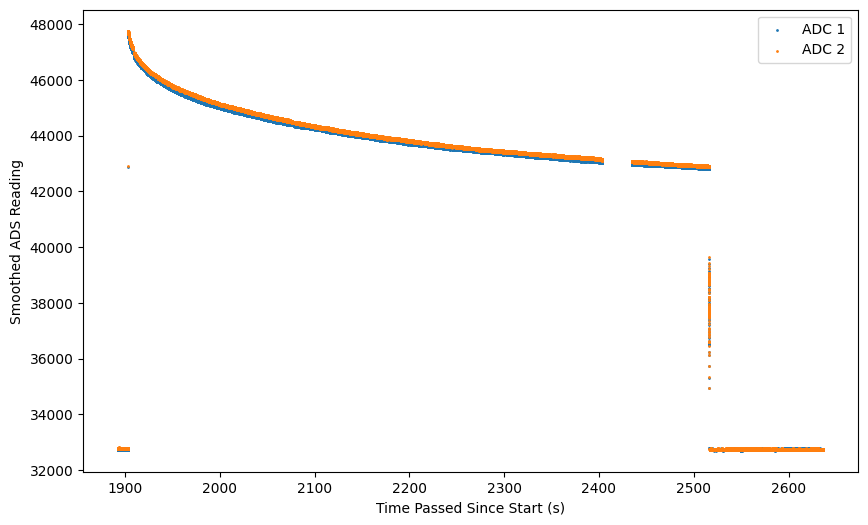

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(cleaned_dfs[5]['time_passed_since_start'], cleaned_dfs[5]['ADS Reading 1 (Smoothed)'], s=1, label='ADC 1')
plt.scatter(cleaned_dfs[5]['time_passed_since_start'], cleaned_dfs[5]['ADS Reading 2 (Smoothed)'], s=1, label='ADC 2')
plt.xlabel('Time Passed Since Start (s)')
plt.ylabel('Smoothed ADS Reading')
plt.legend()
plt.show()

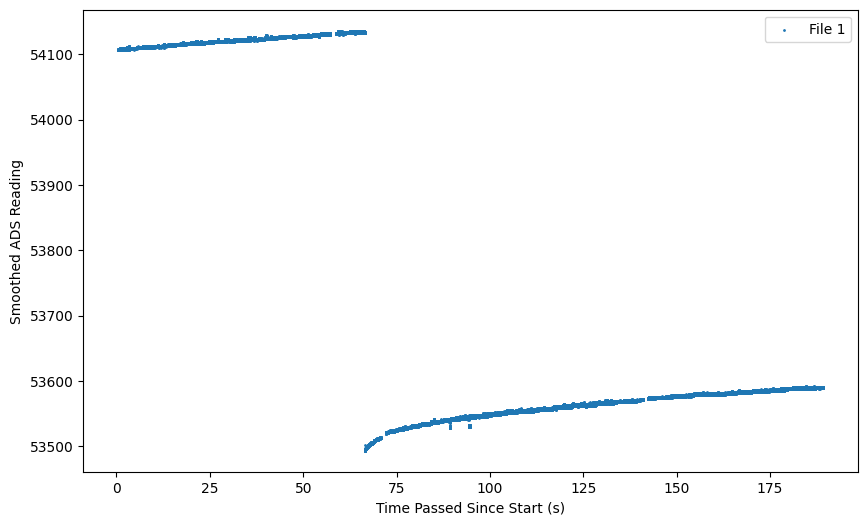

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(cleaned_dfs[2]['time_passed_since_start'], cleaned_dfs[2]['ADS Reading 3 (Smoothed)'], s=1, label='File 1')
plt.xlabel('Time Passed Since Start (s)')
plt.ylabel('Smoothed ADS Reading')
plt.legend()
plt.show()

In [45]:
SELECT = []
IGNORE_ADC2 = False

for index in range(len(cleaned_dfs)):
    if index not in SELECT and len(SELECT) > 0:
        continue
    cleaned_df = cleaned_dfs[index]
    
    # Offset ads1 and ads2 only
    zeroed_ads1 = []
    zeroed_ads2 = []
    ads1_offset = 0
    ads2_offset = 0
    ads1_started = False
    ads2_started = False
    
    cleaned_df["ADS Reading 1 (Smoothed and Offset)"] = cleaned_df["ADS Reading 1 (Smoothed)"]
    if not IGNORE_ADC2:
        cleaned_df["ADS Reading 2 (Smoothed and Offset)"] = cleaned_df["ADS Reading 2 (Smoothed)"]
    
    for i in range(len(cleaned_df)):
        if i % 10000 == 0:
            print(f"Processing index {i}/{len(cleaned_df)} for file {index + 1} / {len(cleaned_dfs)}", end="\r")
        
        # Get a list of reading when no current is flowing
        threshold = 100  # Threshold for determining if current is flowing, can be adjusted based on data distribution
        if cleaned_df["ADS Reading 1 (Smoothed and Offset)"].iloc[i] < threshold:
            if ads1_started:    # Reset the list if back to zero to recalibrate when current stops flowing again
                print("ADS Reading 1 dropped below threshold at index {}. Resetting offset calibration.".format(i))
                zeroed_ads1 = []
                ads1_offset = 0
                ads1_started = False
                
            zeroed_ads1.append(cleaned_df["ADS Reading 1 (Smoothed and Offset)"].iloc[i])
        if not IGNORE_ADC2 and cleaned_df["ADS Reading 2 (Smoothed and Offset)"].iloc[i] < threshold:
            if ads2_started:
                print("ADS Reading 2 dropped below threshold at index {}. Resetting offset calibration.".format(i))
                zeroed_ads2 = [] 
                ads2_offset = 0
                ads2_started = False
                
            zeroed_ads2.append(cleaned_df["ADS Reading 2 (Smoothed and Offset)"].iloc[i])
        
        # Offset the reading when current is flowing to correct for any drift in the sensor. 
        # Only offset when current is flowing to prevent outlier readings.
        if cleaned_df["ADS Reading 1 (Smoothed and Offset)"].iloc[i] >= threshold:
            if len(zeroed_ads1) > 10:
                ads1_started = True
                # At least 10 reading to get avergage offset to prevent outlier       
                ads1_offset = sum(zeroed_ads1) / len(zeroed_ads1)
                
                cleaned_df['ADS Reading 1 (Smoothed and Offset)'] = cleaned_df['ADS Reading 1 (Smoothed and Offset)'] - ads1_offset
                zeroed_ads1 = []
                print("Rezeroing offset at index {}: ads1 offset {}".format(i, ads1_offset))
        if not IGNORE_ADC2 and cleaned_df["ADS Reading 2 (Smoothed and Offset)"].iloc[i] >= threshold:
            if len(zeroed_ads2) > 10:
                ads2_started = True
                # At least 10 reading to get avergage offset to prevent outlier       
                ads2_offset = sum(zeroed_ads2) / len(zeroed_ads2)
                
                cleaned_df['ADS Reading 2 (Smoothed and Offset)'] = cleaned_df['ADS Reading 2 (Smoothed and Offset)'] - ads2_offset
                zeroed_ads2 = []
                print("Rezeroing offset at index {}: ads2 offset {}".format(i, ads2_offset))


In [46]:
SELECT = []

for index in range(len(cleaned_dfs)):
    if index not in SELECT and len(SELECT) > 0:
        continue
    cleaned_df = cleaned_dfs[index]
    
    cleaned_df['Calibrated Current 1'] = cleaned_df['ADS Reading 1 (Smoothed and Offset)'].apply(adc_to_current)
    if not IGNORE_ADC2:
        cleaned_df['Calibrated Current 2'] = cleaned_df['ADS Reading 2 (Smoothed and Offset)'].apply(adc_to_current)

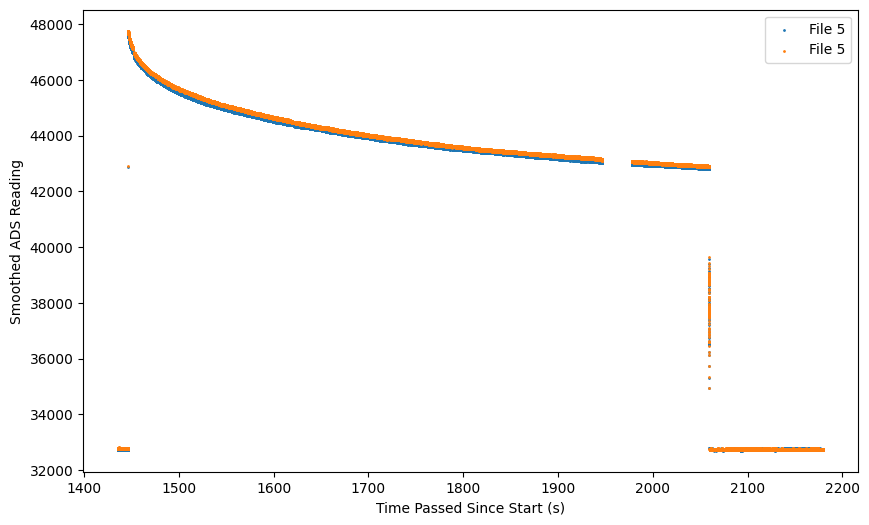

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(cleaned_dfs[5]['time_passed_since_start'], cleaned_dfs[5]['ADS Reading 1 (Smoothed and Offset)'], s=1, label='File 5')
if not IGNORE_ADC2:
    plt.scatter(cleaned_dfs[5]['time_passed_since_start'], cleaned_dfs[5]['ADS Reading 2 (Smoothed and Offset)'], s=1, label='File 5')
plt.xlabel('Time Passed Since Start (s)')
plt.ylabel('Smoothed ADS Reading')
plt.legend()
plt.show()

In [48]:
# Shift time to be continuous across files
prev_end_time = 0
for i in range(len(cleaned_dfs)):
    cleaned_dfs[i]['time_passed_since_start'] += prev_end_time
    prev_end_time = cleaned_dfs[i]['time_passed_since_start'].iloc[-1]

In [49]:
t = 0
for df in cleaned_dfs:
    df['time_passed_since_start'] = df['time_passed_since_start'] - df['time_passed_since_start'].iloc[0] + t
    t = df['time_passed_since_start'].iloc[-1]
    
for df in cleaned_dfs:
    df['Translated Time'] = df['time_passed_since_start'] * 1000  # Convert to milliseconds
    

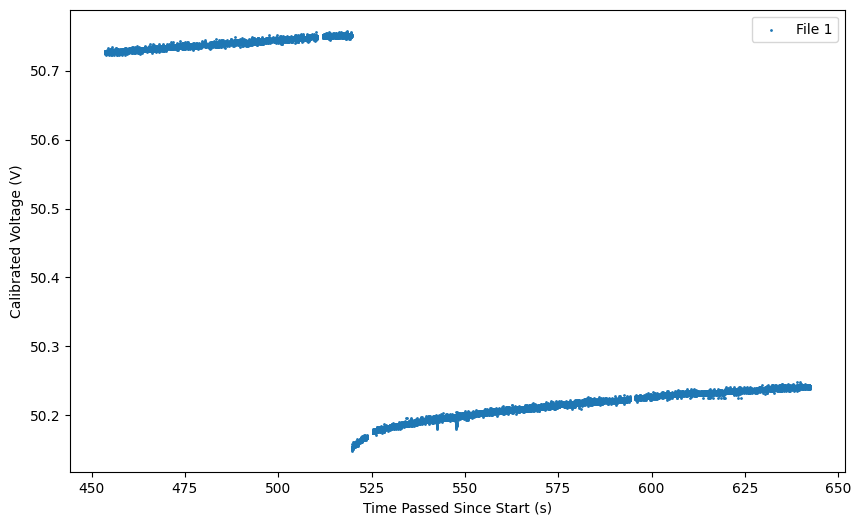

In [50]:
plt.figure(figsize=(10, 6))
plt.scatter(cleaned_dfs[2]['time_passed_since_start'], cleaned_dfs[2]['Calibrated Voltage'], s=1, label='File 1')
plt.xlabel('Time Passed Since Start (s)')
plt.ylabel('Calibrated Voltage (V)')    
plt.legend()
plt.show()

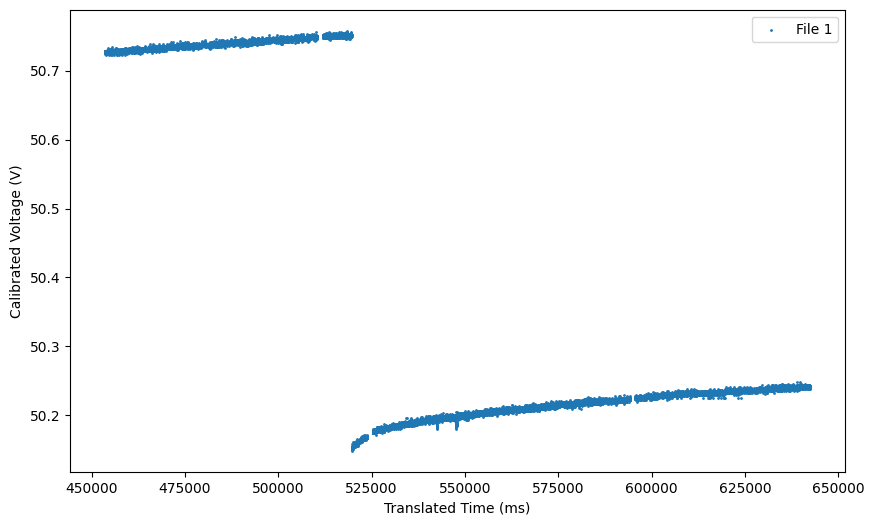

In [51]:
plt.figure(figsize=(10, 6))
plt.scatter(cleaned_dfs[2]['Translated Time'], cleaned_dfs[2]['Calibrated Voltage'], s=1, label='File 1')
plt.xlabel('Translated Time (ms)')
plt.ylabel('Calibrated Voltage (V)')    
plt.legend()
plt.show()

In [52]:
combined_df = pd.concat([cleaned_dfs[i] for i in range(len(cleaned_dfs))], ignore_index=True)
combined_df['Translated Time (minutes)'] = combined_df['Translated Time'] / (1000 * 60)  # Convert ms to minutes

print(combined_df.shape)
print(combined_df.head())

(11362394, 21)
   counter  timediff_us    ch0    ch1    ch2    ch3    ch4    ch5    ch6  ch7  \
0        1     48860088  32737  32798  32760  32762  32764  32767  55913    1   
1        2          942  32755  32806  32760  32764  32764  32766  55914    0   
2        3          938  32756  32821  32760  32762  32763  32766  55913    0   
3        4          939  32723  32833  32760  32763  32764  32767  55914    1   
4        5          938  32731  32814  32760  32763  32764  32765  55914    0   

   ...  ADS Reading 2 (Smoothed)  ADS Reading 3 (Smoothed)  \
0  ...                   32730.0                   55913.0   
1  ...                   32722.5                   55913.5   
2  ...                   32722.0                   55914.0   
3  ...                   32722.0                   55914.0   
4  ...                   32722.0                   55914.0   

   Calibrated Voltage  time_passed_since_start  \
0           52.419237                 0.000000   
1           52.420175    

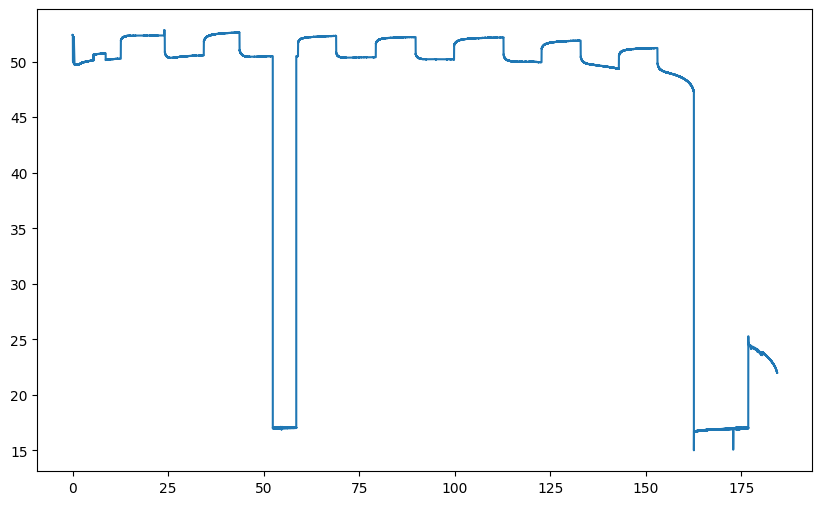

In [53]:
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['Calibrated Voltage'], label='Calibrated Voltage')
plt.show()

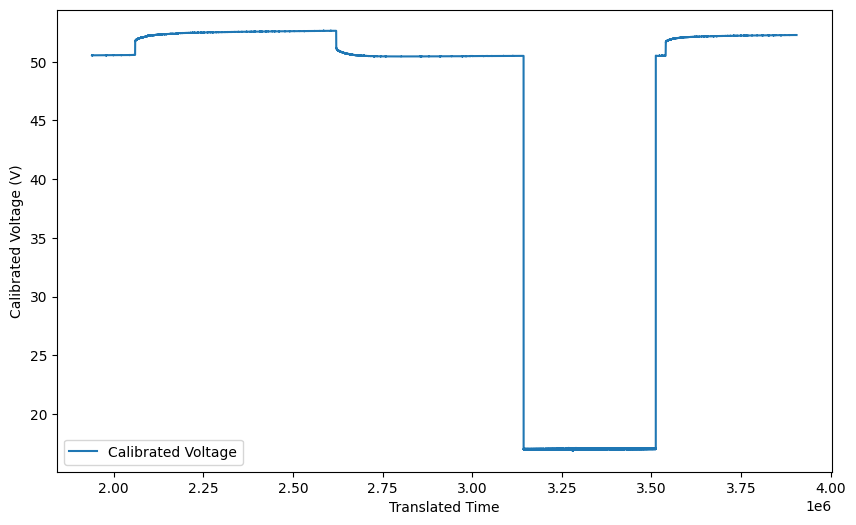

In [42]:
START_POINT = 2000000
END_POINT = 4000000
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time'].iloc[START_POINT:END_POINT], combined_df['Calibrated Voltage'].iloc[START_POINT:END_POINT], label='Calibrated Voltage')
plt.xlabel('Translated Time')
plt.ylabel('Calibrated Voltage (V)')
plt.legend()
plt.show()

In [43]:
combined_df = combined_df.iloc[0: 10000000]

In [55]:
# MAE for ADS1 and ADS2
mean_abs_sum = sum(abs(combined_df["ADS Reading 1 (Smoothed)"] - combined_df["ADS Reading 2 (Smoothed)"]))
mean_absolute_error = mean_abs_sum / len(combined_df)
print("Mean Absolute Error non-offset values (MAE):", mean_absolute_error)

mean_abs_sum = sum(abs(combined_df["ADS Reading 1 (Smoothed and Offset)"] - combined_df["ADS Reading 2 (Smoothed and Offset)"]))
mean_absolute_error = mean_abs_sum / len(combined_df)
print("Mean Absolute Error for offset values (MAE):", mean_absolute_error)

# Mean error
mean_sum = sum((combined_df["ADS Reading 1 (Smoothed)"] - combined_df["ADS Reading 2 (Smoothed)"]))
mean_error = mean_sum / len(combined_df)
print("Mean Error for non-offset values:", mean_error)

mean_sum = sum((combined_df["ADS Reading 1 (Smoothed and Offset)"] - combined_df["ADS Reading 2 (Smoothed and Offset)"]))
mean_error = mean_sum / len(combined_df)
print("Mean Error for offset values:", mean_error)


Mean Absolute Error non-offset values (MAE): 26.793705050185725
Mean Absolute Error for offset values (MAE): 26.793705050185725
Mean Error for non-offset values: -2.715965623089641
Mean Error for offset values: -2.715965623089641


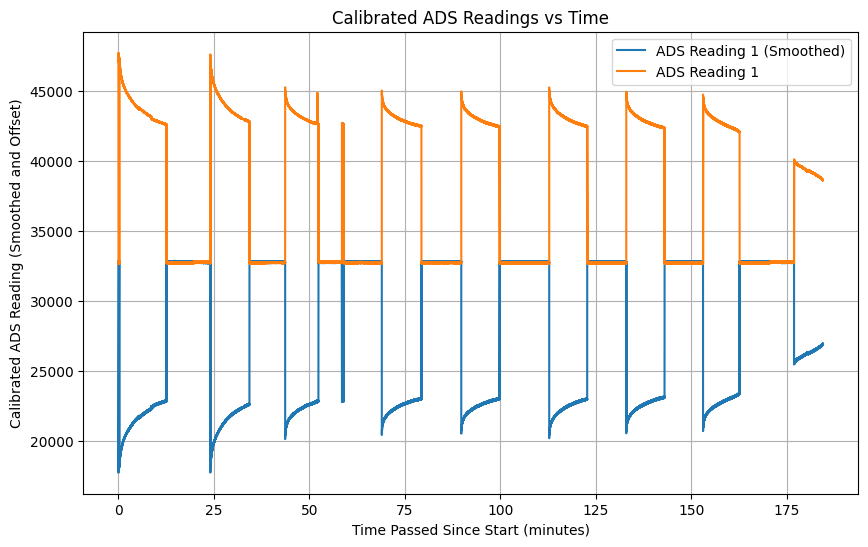

In [56]:

plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['ch1'], label='ADS Reading 1 (Smoothed)')
plt.plot(combined_df['Translated Time (minutes)'], combined_df['ADS Reading 1 (Smoothed and Offset)'], label='ADS Reading 1') 
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Calibrated ADS Reading (Smoothed and Offset)')
plt.title('Calibrated ADS Readings vs Time')
plt.legend()
plt.grid()
plt.show()

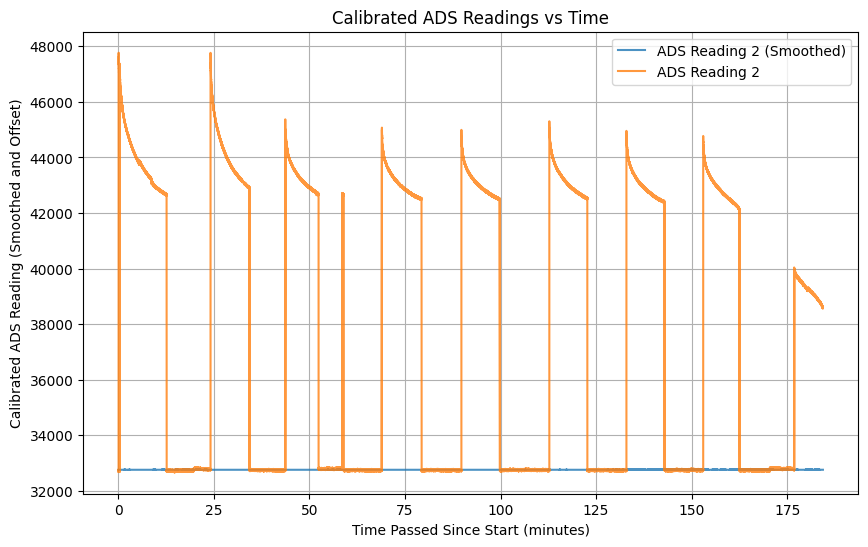

In [57]:

plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['ch2'], label='ADS Reading 2 (Smoothed)',alpha=0.8)
plt.plot(combined_df['Translated Time (minutes)'], combined_df['ADS Reading 2 (Smoothed and Offset)'], label='ADS Reading 2',alpha=0.8)
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Calibrated ADS Reading (Smoothed and Offset)')
plt.title('Calibrated ADS Readings vs Time')
plt.legend()
plt.grid()
plt.show()

In [58]:
if IGNORE_ADC2:
    combined_df['ADS Reading 2 (Smoothed and Offset)'] = None
    combined_df['Calibrated Current 2'] = None
cleaned_combined_df = combined_df[['Translated Time', 'Translated Time (minutes)', 'ADS Reading 1 (Smoothed and Offset)', 'Calibrated Current 1',
                        'ADS Reading 2 (Smoothed and Offset)', 'Calibrated Current 2', 'ADS Reading 3 (Smoothed)', 'Calibrated Voltage']]
    
print(cleaned_combined_df.head())

   Translated Time  Translated Time (minutes)  \
0            0.000                   0.000000   
1            0.942                   0.000016   
2            1.880                   0.000031   
3            2.819                   0.000047   
4            3.757                   0.000063   

   ADS Reading 1 (Smoothed and Offset)  Calibrated Current 1  \
0                              32755.0             -0.031158   
1                              32746.0             -0.053594   
2                              32737.0             -0.076032   
3                              32755.0             -0.031158   
4                              32737.0             -0.076032   

   ADS Reading 2 (Smoothed and Offset)  Calibrated Current 2  \
0                              32730.0             -0.093485   
1                              32722.5             -0.112186   
2                              32722.0             -0.113433   
3                              32722.0             -0.113433   


In [59]:
# Save to csv
create_output_file(override=True, csv_data=cleaned_combined_df)    